# Проект. Исследование стартапов

Автор: Казанцев Павел Павлович

## Введение

Данный проект был создан для финансовой компании, работающей с венчурными инвестициями, которая хочет понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний.

**Целью проекта** является исследование динамики и структуры финансирования стартапов, а также ответы на вопросы, важные для оценки инвестиционных стратегий.

В рамках проекта потребуется выполнить **определенные задачи**:

- Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.

- Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.

- Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.

- Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.

- Сравнить популярность и объёмы разных типов финансирования.

- Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.

- Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.

- Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.


## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.


### 1.1. Вывод общей информации

Загрузим необходимые для работы библиотеки:

In [2]:
# Загрузим необходимые библиотеки для работы
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Загрузим все данные по проекту.

In [3]:
# Выгружаем данные в переменные investments_df и return_df
investments_df = pd.read_csv('https://code.s3.yandex.net/datasets/cb_investments.zip', sep=';', low_memory=False)
return_df = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')

Выведем информацию, которая необходима для принятия решений о предобработке.

In [4]:
# Выведем первые строки датасета investments_df
investments_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Выведем информацию о датасете investments_df
investments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [6]:
# Выведем несколько строк датасета return_df
return_df.head(15)

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
5,2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
6,2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
7,2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
8,2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02


In [7]:
# Выведем информацию о датасете return_df
return_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Датафрейм `investments_df` содержит 40 столбцов и 54294 строки, в которых представлена информация о компаниях и состоявшемся финансировании.

- Названия столбцов правильно отображают содержимое данных и приведены к корректному стилю snake_case, однако столбцы `market` и `funding_total_usd` имеют пробелы в названии, которые нужно удалить.

- У 7 из 40 столбцов некорректный тип данных. Столбцы `founded_at`, `founded_month`, `founded_quarter`, `founded_year`, `first_funding_at`, `mid_funding_at`, `last_funding_at` и `funding_total_usd` необходимо преобразовать в соответсвующие типы даты и числа.

- До предобработки в датафрейме встречаются значения `float` и `object`.

- Все столбцы датафрейма `investments_df` имеют пропущенные значения. От 9% до 45% пропущенных значений в столбцах.

- Значения в столбце `funding_total_usd` нужно удалить запятые и приветсти к числовому типу данных.

Датафрейм `return_df` содержит 14 столбцов и 15 строк, в которых представлена информация об объёмах возвратов по годам и типам финансирования в миллионах долларов.

- Названия столбцов правильно отображают содержимое данных и приведены к корректному стилю snake_case.

- Все столбцы приведены к корректному типу данных. В датафрейме встречаются типы `int` и `float`.

- В датафрейме отсутствуют пропущенные значения.

### 1.2. Предобработка данных

Приведем столбцы к удобному стилю - удалим все пробелы в названиях

In [8]:
investments_df.columns = investments_df.columns.str.strip()

Уберем в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [9]:
# Уберем все строковые знаки из столбца
investments_df['funding_total_usd'] = investments_df['funding_total_usd'].str.replace(',', '').replace(' -   ', '')

In [10]:
# Приведем столбец к числовому типу
investments_df['funding_total_usd'] = pd.to_numeric(investments_df['funding_total_usd'], errors='coerce', downcast='float')
investments_df['funding_total_usd']

0        90000000.0
1         2000000.0
2         9000000.0
3         7700000.0
4          540000.0
            ...    
54289           NaN
54290           NaN
54291           NaN
54292           NaN
54293           NaN
Name: funding_total_usd, Length: 54294, dtype: float64

Обработаем типы данных в столбцах, которые хранят значения даты и времени.

Столбцы `founded_at`, `founded_month`, `founded_quarter`, `first_funding_at`, `mid_funding_at`, `last_funding_at`

In [11]:
# Посмотрим какой формат у столбцов с датой
investments_df[['founded_at', 'founded_month', 'founded_quarter', 'first_funding_at', 'mid_funding_at', 'last_funding_at']].sample(10)

,founded_at,founded_month,founded_quarter,first_funding_at,mid_funding_at,last_funding_at
11660,2007-01-01,2007-01,2007-Q1,2007-08-01,2007-08-01,2008-03-08
10401,2006-01-01,2006-01,2006-Q1,2010-04-26,2011-05-26,2011-05-26
8810,2005-01-01,2005-01,2005-Q1,2009-07-24,NaN,2009-07-24
49124,NaN,NaN,NaN,2014-10-06,NaN,2014-10-06
12519,2007-01-01,2007-01,2007-Q1,2011-10-31,2011-10-31,2011-10-31
23496,2011-01-01,2011-01,2011-Q1,2011-10-27,2011-10-27,2013-06-05
12191,2007-01-01,2007-01,2007-Q1,2010-02-01,2010-02-01,2013-04-05
22197,2010-08-16,2010-08,2010-Q3,2011-06-10,2011-06-10,2011-06-10
5752,2002-01-01,2002-01,2002-Q1,2009-05-29,2009-05-29,2012-02-07
569,1983-01-01,1983-01,1983-Q1,1994-09-12,NaN,1994-09-12


In [12]:
# Приведем типы данных к дате, учитывая форматы дат
for col in ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']:
    investments_df[col] = pd.to_datetime(investments_df[col], format='%Y-%m-%d', errors='coerce')
    print(f'Тип столбца {col} после преобразования: {investments_df[col].dtypes}')

# Приведем месяц основания к дате, сохранив формат
investments_df['founded_month'] = pd.to_datetime(investments_df['founded_month'], format='%Y-%m', errors='coerce')
print(f'Тип столбца founded_month после преобразования: {investments_df['founded_month'].dtypes}')

# Приведем квартал основания в период и далее в формат datetime64
investments_df['founded_quarter'] = pd.PeriodIndex(investments_df['founded_quarter'], freq='Q').to_timestamp()
print(f'Тип столбца founded_quarter после преобразования: {investments_df['founded_quarter'].dtypes}')

# Создадим новый столбец на основе founded_quarter, который будет хранить только цифру квартала основания
investments_df['founded_quarter_number'] = investments_df['founded_quarter'].dt.quarter

Тип столбца founded_at после преобразования: datetime64[ns]
Тип столбца first_funding_at после преобразования: datetime64[ns]
Тип столбца mid_funding_at после преобразования: datetime64[ns]
Тип столбца last_funding_at после преобразования: datetime64[ns]
Тип столбца founded_month после преобразования: datetime64[ns]
Тип столбца founded_quarter после преобразования: datetime64[ns]


В датафрейме `return_df` сделаем столбец `year` индексом всего датасета.

In [13]:
return_df = return_df.set_index('year')
return_df

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00


Очистим данные от полных пропусков, где каждая строка имеет пропущенное значение. Обработаем текстовые данные. Пропуски в текстовых столбцах заполним заглушками.

In [14]:
# Сохраним полностью пустые строки в переменную
empty_cols = investments_df[investments_df.isna().all(axis=1)]

# Удалим полностью пустые строки и запишем в новый дф clean_investments_df
clean_investments_df = investments_df.dropna(how='all').copy()

# Cоздадим маску для текстовых столбцов
str_col = clean_investments_df.select_dtypes(include='object').columns

# Заполним пропуски текстовые столбцы пустыми строками
clean_investments_df[str_col] = clean_investments_df[str_col].fillna('')

Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`. Избавимся от тех строк, которые не содержат данных о финансировании.

In [15]:
# Проверим очищенный от полных пропусков датафрейм на полные дубликаты
clean_investments_df.duplicated().sum()

np.int64(0)

In [16]:
# Сохраним кол-во пропусков в данных о финансировании
empty_usd = clean_investments_df['funding_total_usd'].isna().sum()

# Удалим пропущенные значения в столбце funding_total_usd
clean_investments_df.dropna(subset='funding_total_usd', inplace=True)

Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.



In [17]:
# Проверим пропуски в столбцах first_funding_at, last_funding_at и mid_funding_at
clean_investments_df[['first_funding_at', 'mid_funding_at', 'last_funding_at']].isna().sum()

first_funding_at        2
mid_funding_at      13676
last_funding_at         0
dtype: int64

In [18]:
# Удалим 2 строки с пропуском в first_funding_at
clean_investments_df.dropna(subset='first_funding_at', inplace=True)

In [19]:
# Создадим маску с условием что mid_funding_at пропущено
mask = clean_investments_df['mid_funding_at'].isna()

# Переведем даты в int для расчета
first_ns = clean_investments_df.loc[mask, 'first_funding_at'].astype('int64')
last_ns = clean_investments_df.loc[mask, 'last_funding_at'].astype('int64')

# Среднее арифметическое
mid_ns = (first_ns + last_ns) // 2

clean_investments_df.loc[mask, 'mid_funding_at'] = pd.to_datetime(mid_ns).dt.strftime('%Y-%m-%d')

# Проверим пропуски в столбцах
clean_investments_df[['first_funding_at', 'mid_funding_at', 'last_funding_at']].isna().sum()

first_funding_at    0
mid_funding_at      0
last_funding_at     0
dtype: int64

Оценим полноту данных и сделаем предварительный вывод о том, достаточно ли данных для решения задач проекта.

In [20]:
# Проверим состояние данных осталось после предобработки 
print(f'Строк удалено: {investments_df.shape[0] - clean_investments_df.shape[0]}, {round((investments_df.shape[0] - clean_investments_df.shape[0]) / investments_df.shape[0] * 100, 2)}%')
print(f'Строк осталось: {clean_investments_df.shape[0]}, {round(clean_investments_df.shape[0] / investments_df.shape[0] * 100, 2)}%')
print()
print(f'Удалено строк, с пропусками во всех столбцах: {empty_cols.shape[0]}, {round(empty_cols.shape[0] / investments_df.shape[0] * 100, 2)}%')
print(f'Удалено строк, не содержащих информацию о финансировании: {empty_usd}, {round(empty_usd / investments_df.shape[0] * 100, 2)}%')
print()
print('Также мы удалили 2 строки с пропусками из столбца first_funding_at для расчета значений')

Строк удалено: 13389, 24.66%
Строк осталось: 40905, 75.34%

Удалено строк, с пропусками во всех столбцах: 4856, 8.94%
Удалено строк, не содержащих информацию о финансировании: 8531, 15.71%

Также мы удалили 2 строки с пропусками из столбца first_funding_at для расчета значений


В ходе предобработки мы провели следующие операции:

- Привели названия столбцов к удобному стилю - удалили пробелы в названиях.

- Преобразовали столбцы `founded_at`, `founded_month`, `founded_quarter`, `first_funding_at`, `mid_funding_at`, `last_funding_at`, содержащие дату в соответсвующий тип c сохранением формата.

- Создали новый столбец `founded_quarter_number` на основе `founded_quarter`, содержащий номер квартала.

- В датафрейме `return_df` сделали столбец `year` индексом всего датасета.

- Очистили данные от полных пропусков, где каждая строка имеет пропущенное значение, было удалено `4856 строки, 8.94%`. Пропуски в текстовых столбцах заполним заглушками.

- Обработали полные дубликаты в данных и пропуски в `funding_total_usd`. Избавились от тех строк, которые не содержат данных о финансировании, удалили `8531, 15.71%`.

- Заполнили пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков взяли приблизительно середину интервала между этими двумя датами.

В общем и целом, мы удалили 13389 строк, это 24.66% от исходного датафрейма `investments_df`.

В итоге у нас остались данные в объеме 40905 строк, это 75.34% исходного датафрейма, которые мы сохранили в новый датафрейм `clean_investments_df`

75% данных это достаточный объем для решения задача проекта.



## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

In [21]:
# Посмотрим нужные столбцы
clean_investments_df[['funding_rounds', 'first_funding_at', 'last_funding_at']].head()

,funding_rounds,first_funding_at,last_funding_at
0,1.0,2014-01-06,2014-01-06
1,1.0,2014-05-15,2014-05-15
2,1.0,2009-07-02,2009-07-02
3,3.0,2013-11-21,2014-11-03
4,1.0,2014-01-14,2014-01-14


In [22]:
# Переведем funding_rounds в целочисленные тип
clean_investments_df['funding_rounds'] = clean_investments_df['funding_rounds'].astype('int8')

In [23]:
# Напишем фунцию для категоризации финансирования
def create_category(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'

    delta_days = (row['last_funding_at'] - row['first_funding_at']).days
    if delta_days < 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'


In [24]:
# Создаем столбец и применяем функцию
clean_investments_df['category_finance'] = clean_investments_df.apply(create_category, axis=1)

In [25]:
# Посмотрим распределение компаний по категориям финансирования
percent_name = (clean_investments_df['category_finance'].value_counts(normalize=True) * 100).sort_values(ascending=False)
percent_name

category_finance
Единичное финансирование          58.948784
Срок финансирования более года    30.277472
Срок финансирования до года       10.773744
Name: proportion, dtype: float64

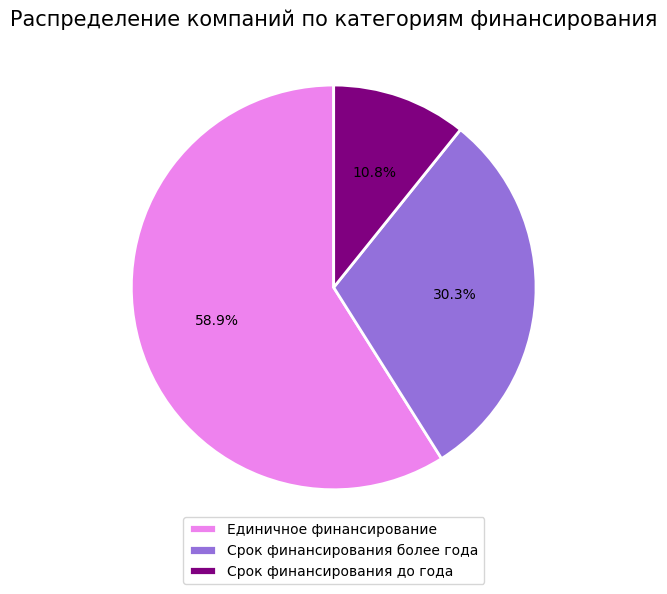

In [26]:
# Построим круговую диаграмму для визуализации распределения
fig, ax = plt.subplots(figsize = (10, 6))

percent_name.plot(
    kind='pie',
    ylabel='',
    legend=True,
    colors=['violet','mediumpurple','purple'],
    startangle=90,
    autopct='%1.1f%%',
    labeldistance=None,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

ax.set_ylabel('')
ax.set_title('Распределение компаний по категориям финансирования', fontsize=15)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1))
plt.tight_layout()
plt.show()

Большинство компаний (**58.9%**) финансировалось всего один раз


In [27]:
# Посмотрим распределение объема инвестиций по категориям финансирования
sums = clean_investments_df.groupby('category_finance')['funding_total_usd'].sum().sort_values(ascending=False)
sums

category_finance
Срок финансирования более года    4.037394e+11
Единичное финансирование          1.993044e+11
Срок финансирования до года       4.785555e+10
Name: funding_total_usd, dtype: float64

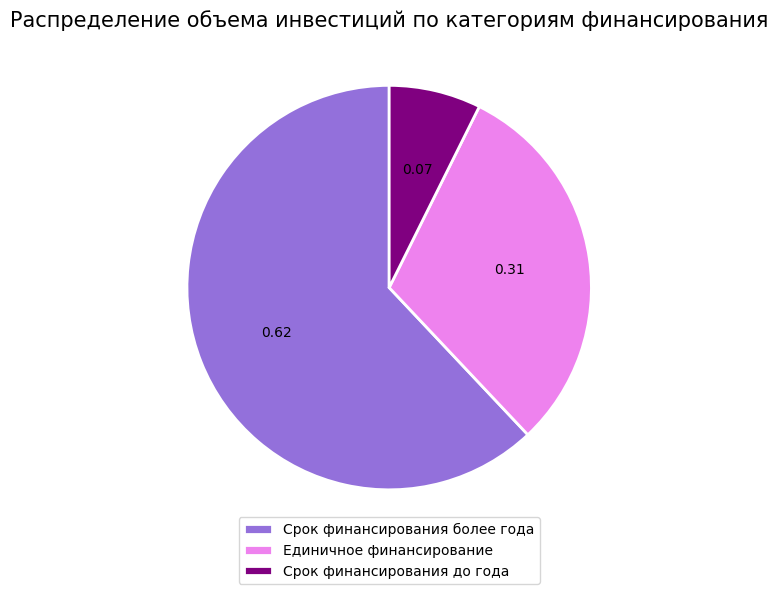

In [28]:
# Построим график для визуализации объема инвестиции по категориям
fig, ax = plt.subplots(figsize = (10, 6))

sums.plot(
    kind='pie',
    ylabel='',
    legend=True,
    colors=['mediumpurple', 'violet', 'purple'],
    startangle=90,
    autopct=lambda p: f'{p/100:.2f}',
    labeldistance=None,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

ax.set_ylabel('')
ax.set_title('Распределение объема инвестиций по категориям финансирования', fontsize=15)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1))
plt.tight_layout()
plt.show()

Компании, которые финансируются более года, имеют самый большую долю вложенных инвестиций - **0.62**

На рынке доминируют стартапы, ограничившиеся единичным раундом финансирования, однако подавляющая часть инвестиций сосредоточена у компаний с длинным финансовым циклом (более года между первым и последним раундом). Это отражает тенденцию: наиболее привлекательными для инвесторов являются компании, способные на протяжении длительного времени привлекать новые средства, а массовый сегмент "разовых" стартапов получает куда меньшую долю капитала.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Построим график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

In [29]:
# Cоздадим дф для группировки и агрегации компаний по сегменту
group_market = clean_investments_df.groupby('market')['name'].count().sort_values(ascending=False).reset_index()

Дополнительно построим график распределения компаний в категории: Массовые > 120 компаний в сегменте, Средние от 35 до 120 включительно, Нишевые до 35 компаний

<Figure size 1200x600 with 0 Axes>

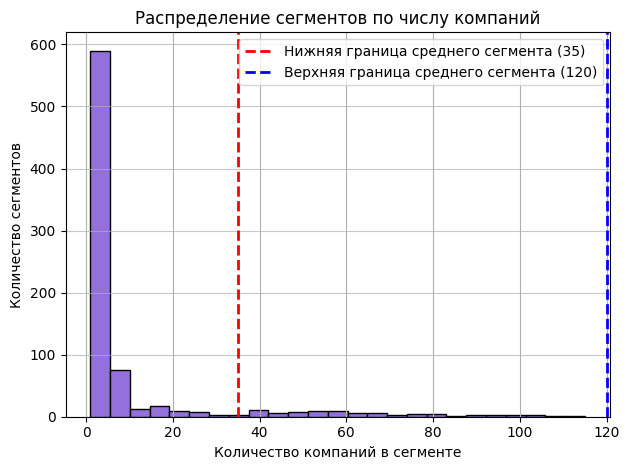

In [30]:
plt.figure(figsize=(12, 6))

group_market[group_market['name'] <= 120].hist(
    bins=25,
    color='mediumpurple',
    edgecolor='black'
)

# Вертикальные линии для границ
plt.axvline(x=35, color='red', linestyle='--', linewidth=2, label='Нижняя граница среднего cегмента (35)')
plt.axvline(x=120, color='blue', linestyle='--', linewidth=2, label='Верхняя граница среднего сегмента (120)')

plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.title('Распределение сегментов по числу компаний')
plt.legend()
plt.grid(axis='y', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()

In [31]:
#Cоздадим новый столбец категории сегмента на основе посчитанных значений кол-ва компаний
group_market['category_market'] = pd.cut(group_market['name'], bins=[0, 35, 121, 10000], labels=['Нишевые', 'Средние', 'Массовые'], right=False)

# Соеденим датафреймы по сегменту, исключая дубликаты
clean_investments_df = clean_investments_df.merge(group_market[['market', 'category_market']].drop_duplicates(subset='market'), on='market', how='left')

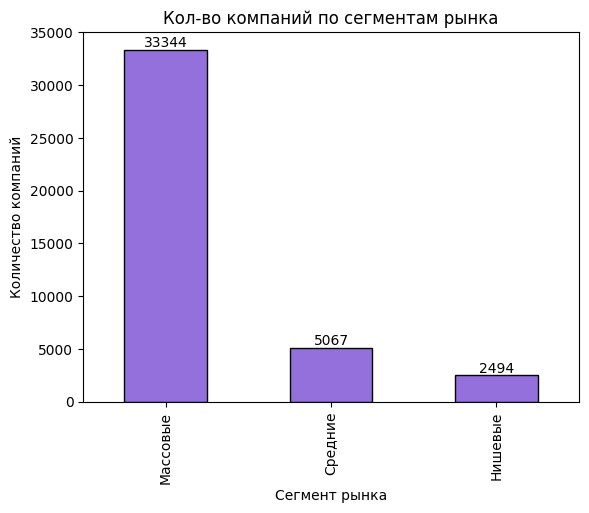

In [32]:
# Построим визуализацию для отображения кол-ва компаний по сегменту

ax = clean_investments_df['category_market'].value_counts().plot(
    kind='bar',
    color='mediumpurple',
    edgecolor='black'
)

ax.bar_label(ax.containers[0], label_type='edge', fmt='%.0f')

plt.ylabel('Количество компаний')
plt.xlabel('Сегмент рынка')
plt.title('Кол-во компаний по сегментам рынка')
plt.show()

В **массовом** сегменте (33344) находится бОльшая часть всех компаний - **81.5%**

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполним с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [33]:
# Напишем функцию, которая будет заменять значения в market в зависимости от category_market
def repalce_market(row):
    if row['category_market'] == 'Нишевые':
        return 'niche'
    if row['category_market'] == 'Средние':
        return 'mid'

    return row['market']

In [34]:
# Применяем функцию
clean_investments_df['market'] = clean_investments_df.apply(repalce_market, axis=1)

In [35]:
# Проверяем работу функции
clean_investments_df[(clean_investments_df['category_market'] == 'Нишевые') |
                     (clean_investments_df['category_market'] == 'Средние')][['market', 'category_market']].sample(15)

,market,category_market
30503,mid,Средние
25610,mid,Средние
28919,mid,Средние
11190,niche,Нишевые
22559,mid,Средние
28221,mid,Средние
26905,niche,Нишевые
30164,niche,Нишевые
8378,niche,Нишевые
31266,mid,Средние


## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

In [36]:
# Меняем формат отображения чисел типа float
pd.set_option('display.float_format', '{:.2f}'.format)

In [37]:
# Посмотрим статистики по общему объему финансирования
clean_investments_df['funding_total_usd'].describe()

count         40905.00
mean       15912465.55
std       168682923.56
min               1.00
25%          350000.00
50%         2000000.00
75%        10000000.00
max     30079503000.00
Name: funding_total_usd, dtype: float64

Среднее значение (**15.9 млн**) почти в 8 раз выше медианы (**2 млн**), скорее всего из-за выбросов в виде крупных финансирований.

Данные содержат огромный разбос значений, буквально **от 1 доллара до 30 млрд. долларов** - стандтатное отклонение ~168 млн.

Для определения типичных значений можно использовать **медиану 2 млн**, так как она устойчива к выбросам.

Для визуализации распределения финансирования выберем **диаграмму размаха**, так как данные содержат большое количество выбросов и распределены неравномерно. Такой график позволит выявить ключевые характеристики распределения, оценить медиану, разброс данных и обнаружить выбросы. Для наглядности отобразим на графике только значения **ниже 95 процентиля**, так как данные содержат выбросы с очень большими значениями.

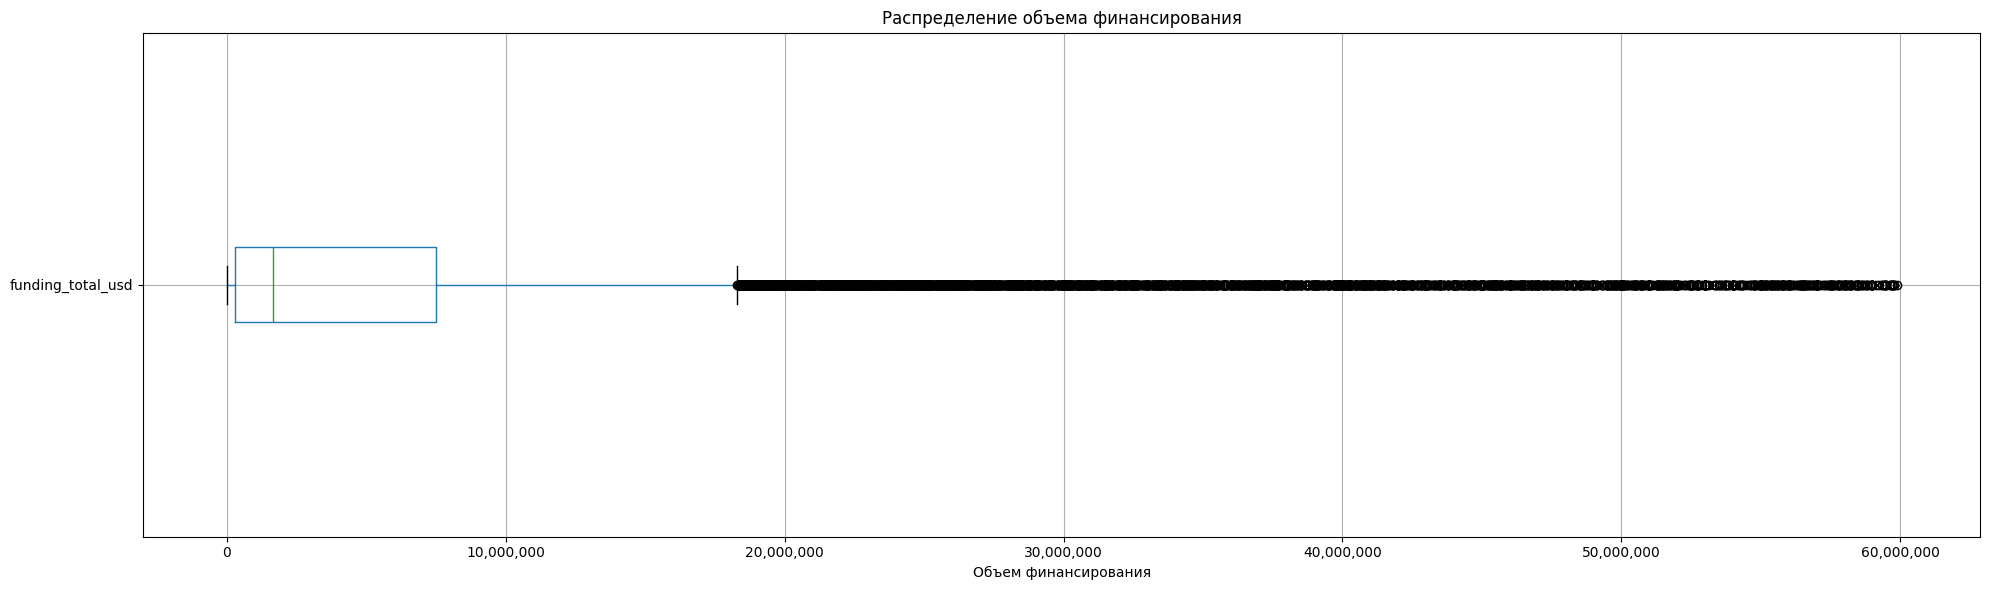

In [38]:
# Диаграмма размаха
ax = clean_investments_df[clean_investments_df['funding_total_usd'] < clean_investments_df['funding_total_usd'].quantile(0.95)].boxplot(
    column='funding_total_usd', vert=False, figsize=(20, 6)
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
plt.xlabel('Объем финансирования')
plt.title('Распределение объема финансирования')
plt.tight_layout()
plt.show()


На графике видим, что **выбивающимися** объемами финансирования являются суммы **после 18 млн.**

**Типичные значения** объема финансирования, который получили компании находится в диапазоне **от 350к до 10 млн. долларов**

Определим компании с аномальным объёмом общего финансирования — используем метод IQR отдельно по каждому сегменту. Все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

In [39]:
# Создадим дф, где посчитаем для каждого сегмента Q1 Q3 IQR
bounds = clean_investments_df.groupby('market')['funding_total_usd'].agg(
    Q1 = lambda x: x.quantile(0.25),
    Q3 = lambda x: x.quantile(0.75),
    IQR = lambda x: x.quantile(0.75) - x.quantile(0.25)
)

# Определим верхнюю и нижнюю границу для выбросов
bounds['lower'] = bounds['Q1'] - 1.5 * bounds['IQR']
bounds['upper'] = bounds['Q3'] + 1.5 * bounds['IQR']

# Округлим значения
bounds[['lower', 'upper']] = bounds[['lower', 'upper']].round(0)

bounds.head()

,Q1,Q3,IQR,lower,upper
market,,,,,
,54488.00,2200000.00,2145512.00,-3163780.00,5418268.00
Advertising,574126.25,12000000.00,11425873.75,-16564684.00,29138811.00
Analytics,500000.00,11700000.00,11200000.00,-16300000.00,28500000.00
Apps,98696.50,2184787.50,2086091.00,-3030440.00,5313924.00
Automotive,268888.75,10000000.00,9731111.25,-14327778.00,24596667.00


In [40]:
# Объеденим расчетный дф с основным дф
clean_investments_df = clean_investments_df.merge(
    bounds[['lower', 'upper']],
    left_on='market',
    right_index=True,
    how='left'
)

# Cоздадим столбец для выявления компаний с аномальным финансированием
clean_investments_df['is_outlier'] = (
    (clean_investments_df['funding_total_usd'] < clean_investments_df['lower']) | 
    (clean_investments_df['funding_total_usd'] > clean_investments_df['upper'])
)

# Проверим результат
clean_investments_df[['name', 'market', 'funding_total_usd', 'lower', 'upper', 'is_outlier']].head(10)

,name,market,funding_total_usd,lower,upper,is_outlier
0,Harvard University,Education,90000000.00,-7506042.00,13043404.00,True
1,University of New Brunswick,,2000000.00,-3163780.00,5418268.00,False
2,DuPont,mid,9000000.00,-10890841.00,18818069.00,False
3,University of Michigan,Education,7700000.00,-7506042.00,13043404.00,False
4,Case Western Reserve University,Education,540000.00,-7506042.00,13043404.00,False
5,Xavier University,,19000000.00,-3163780.00,5418268.00,True
6,Tulane University,Education,12000000.00,-7506042.00,13043404.00,False
7,Duke University,Education,8700000.00,-7506042.00,13043404.00,False
8,"Virginia Commonwealth University, Richmond",,6000000.00,-3163780.00,5418268.00,True
9,WeGame,Social Media,3500000.00,-4200002.00,7320002.00,False


In [41]:
# Cгруппируем по сегменту и посчитаем выбросы
outlier_stats = clean_investments_df.groupby('market')['is_outlier'].agg(
    total = 'count',
    outliers = 'sum',
    share = lambda x: x.sum() / x.count()
).sort_values('share', ascending=False)

# Выведем топ-10 сегментов по доле выбросов
outlier_stats.head(10)

,total,outliers,share
market,,,
Real Estate,251,45,0.18
Technology,229,37,0.16
Search,242,39,0.16
Entertainment,137,22,0.16
Software,137,22,0.16
Cloud Computing,131,21,0.16
Big Data,140,22,0.16
SaaS,224,35,0.16
E-Commerce,129,20,0.16


In [42]:
# Определеним компании, которые получили аномальное финансирование
company_with_outliers = clean_investments_df[clean_investments_df['is_outlier'] == True]['name']
company_with_outliers

0                                Harvard University
5                                 Xavier University
8        Virginia Commonwealth University, Richmond
10                                        VideoSurf
13                            University of Florida
                            ...                    
40888                                Baedal Minjeok
40890                                      Genomics
40896                               Ascendis Pharma
40899                                          Moko
40903                                        Xeltis
Name: name, Length: 5204, dtype: object

При анализе инвестиционного климата и темпов роста по рынкам стоит учитывать, что ряд сегментов из топа по выбросам не всегда подходит для расчёта "средней температуры по больнице". Компании с аномально большими инвестициями могут искусственно увеличивать значения суммарного финансирования и искажать выводы о реальном положении дел на отраслевом уровне.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [43]:
# Создадим отдельный дф 
data_2014 = clean_investments_df.copy()

# Создадим столбцы с месяцем и годом
data_2014['year'] = data_2014['mid_funding_at'].dt.year
data_2014['month'] = data_2014['mid_funding_at'].dt.month

# Посмотрим на кол-во данных по месяцам в 2014 году, чтобы определить полноту
data_2014 = data_2014[data_2014['year'] == 2014]
data_2014.groupby('month').size()

month
1     739
2     600
3     676
4     645
5     600
6     740
7     687
8     559
9     547
10    497
11    306
12     23
dtype: int64

Так как в датасете есть данные о финансировании за последний день года и о компаниях, основанных в последний месяц года, можем считать, что данные за 2014 год полные.

In [44]:
# Оставим в дф данные без выбросов
clean_investments_df = clean_investments_df[clean_investments_df['is_outlier'] == False]

In [45]:
# Считаем суммарное количество раундов по годам
round_per_year = clean_investments_df.groupby(clean_investments_df['mid_funding_at'].dt.year)['funding_rounds'].sum()

# Выбираем годы с >= 50 раундами
valid_years = round_per_year[round_per_year >= 50].index.to_list()

# Фильтруем только компании, у которых год mid_funding_at входит в valid_years
clean_investments_df = clean_investments_df[clean_investments_df['mid_funding_at'].dt.year.isin(valid_years)]

# Проверяем года 
clean_investments_df['mid_funding_at'].dt.year.unique()

array([2014, 2009, 2013, 2007, 2012, 2010, 2008, 2011, 2005, 2004, 2006,
       2001, 2002, 2000, 2003], dtype=int32)

### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируясь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [46]:
# Добавим все виды финансирования в список
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed',
                 'convertible_note', 'debt_financing', 'angel', 'grant', 
                 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

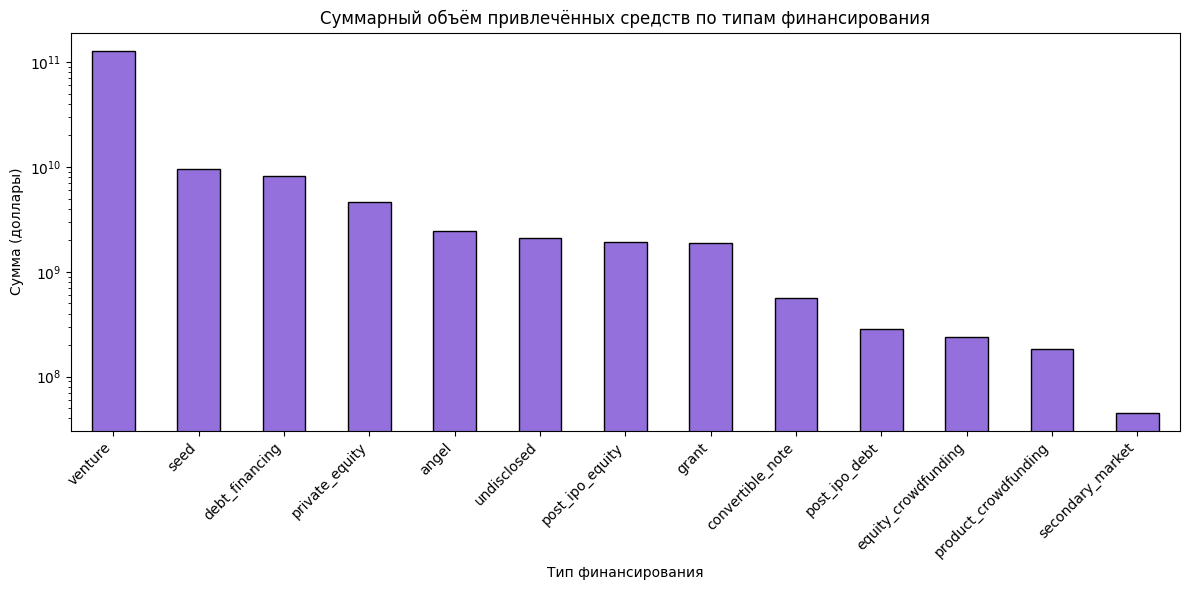

Объем финансирования:
venture                128808764106.00
seed                     9471515513.00
debt_financing           8138443019.00
private_equity           4659295937.00
angel                    2467189788.00
undisclosed              2100641553.00
post_ipo_equity          1936460276.00
grant                    1898560474.00
convertible_note          562971826.00
post_ipo_debt             286809099.00
equity_crowdfunding       237960645.00
product_crowdfunding      183793920.00
secondary_market           45285796.00
dtype: float64


In [47]:
# Суммируем по каждому столбцу
total_volume = clean_investments_df[funding_types].sum().sort_values(ascending=False)

# Построим столбчатую диаграмму
plt.figure(figsize=(12, 6))
total_volume.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Суммарный объём привлечённых средств по типам финансирования')
plt.xlabel('Тип финансирования')
plt.yscale('log') # логарифмическая шкала, чтобы было видно разницу, из-за большого разброса
plt.ylabel('Сумма (доллары)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Объем финансирования:")
print(total_volume)

Абсолютным лидером по привлечению финансирования являются **венчурные инвестиции - 128.8 млрд.**

Далее идут: seed(посевные), debt_financing(долговое финансирование), private_equity(частные вложения) и angel(бизнес-ангелы)
            

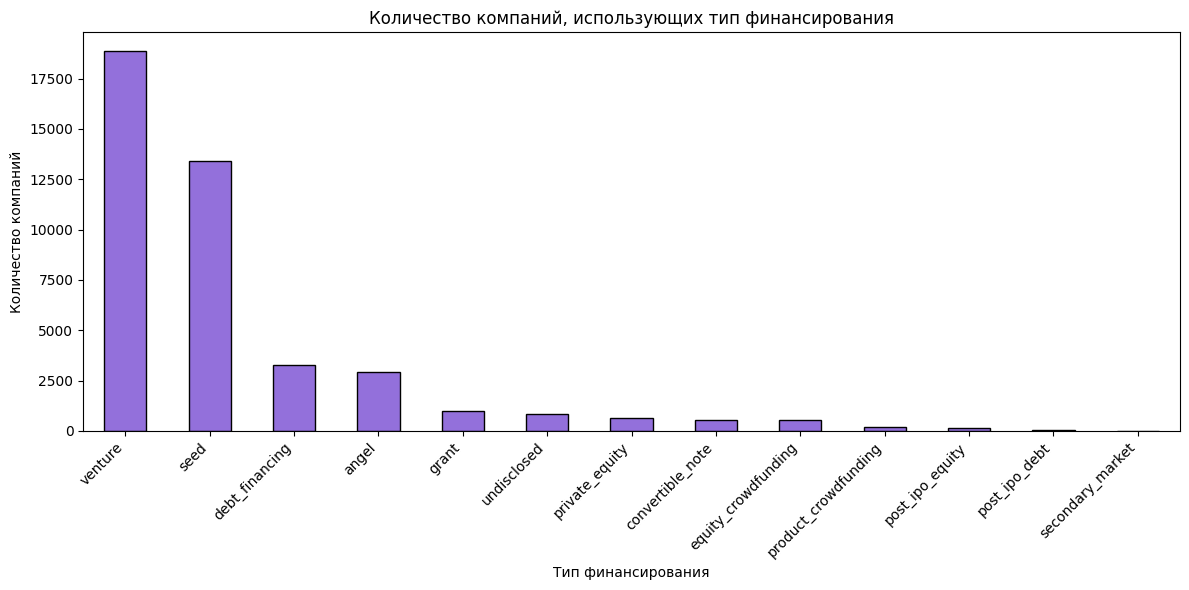

Популярность финансирования:
venture                 18860
seed                    13391
debt_financing           3261
angel                    2943
grant                    1001
undisclosed               814
private_equity            630
convertible_note          520
equity_crowdfunding       515
product_crowdfunding      204
post_ipo_equity           165
post_ipo_debt              28
secondary_market            7
dtype: int64


In [48]:
popularity = (clean_investments_df[funding_types] > 0).sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
popularity.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Количество компаний, использующих тип финансирования')
plt.xlabel('Тип финансирования')
plt.ylabel('Количество компаний')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Популярность финансирования:")
print(popularity)

Как и по объему финансирования выделяются венчурные, посевные, долговые финансирования, а также финансирование от бизнес-ангелов.

При этом можно выделить **гранты(grant)**, компании их получают часто, но объем маленький относительно других типов.

Наоборот у **частных вложений(private_equity)**, объем инвестиций большой, но компании редко пользуются этим типов финансирования.

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

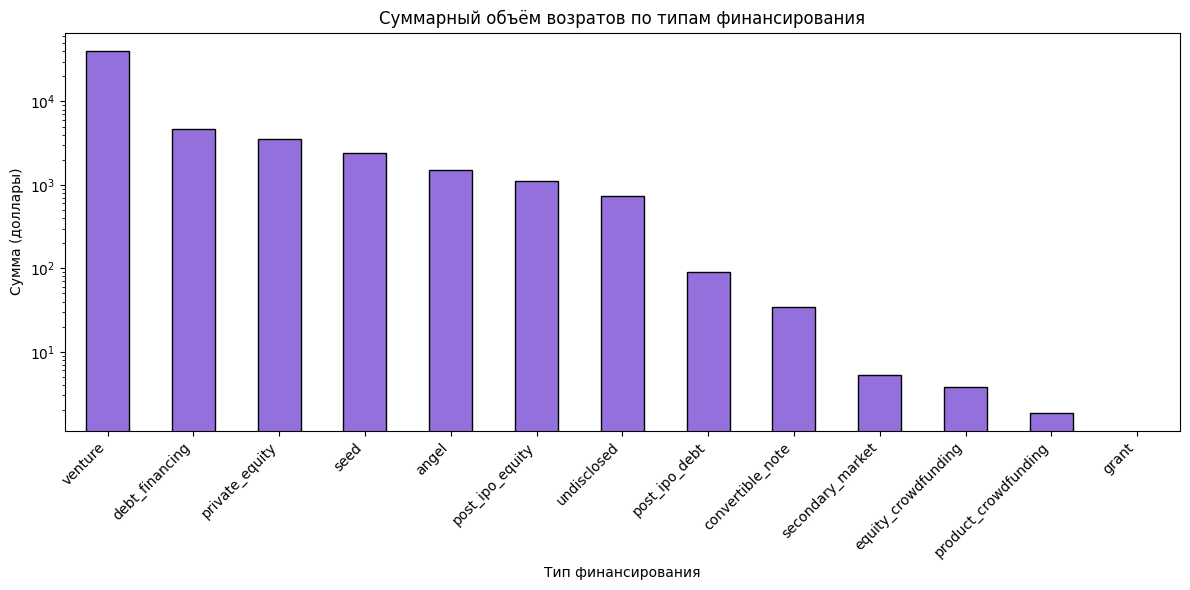

Объем возврата средств от финансирования (млн. $):
venture                40578.62
debt_financing          4734.85
private_equity          3587.33
seed                    2382.24
angel                   1509.23
post_ipo_equity         1104.96
undisclosed              730.88
post_ipo_debt             91.03
convertible_note          34.79
secondary_market           5.20
equity_crowdfunding        3.83
product_crowdfunding       1.86
grant                      0.00
dtype: float64


In [49]:
total_volume_return = return_df[funding_types].sum().sort_values(ascending=False)

# Построим столбчатую диаграмму
plt.figure(figsize=(12, 6))
total_volume_return.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Суммарный объём возратов по типам финансирования')
plt.xlabel('Тип финансирования')
plt.yscale('log') # логарифмическая шкала, чтобы было видно разницу, из-за большого разброса
plt.ylabel('Сумма (доллары)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Объем возврата средств от финансирования (млн. $):")
print(total_volume_return)

Абсолютным лидером в возврате средств является **венчурные инвестиции - 40.5 млрд.**

Далее идут: долговое финансирование - 4.7 млрд, частные вложения - 3.5 млрд, посевные инвестиции 2.3 млрд.

Гранты вернули 0 вложенных средств

Рынок стартапов в основном живёт на венчурном и посевном финансировании, причём венчурные инвестиции и по сумме, и по охвату доминируют на рынке. Для отдельных крупных сделок важную роль играют долговое и прямое инвестирование, однако такие стратегии подходят не всем и довольно редки. Малые и инновационные форматы (краудфандинг, гранты, ангельские инвестиции) остаются нишевыми по капитализации, несмотря на свою популярность среди молодых стартапов. Возврат инвестиций также идёт прежде всего по основным и крупнейшим видам финансирования.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Используем данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответим на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [50]:
# Расситаем средний объем одного раунда финансирования
clean_investments_df['mean_value_round'] = clean_investments_df['funding_total_usd'] / clean_investments_df['funding_rounds']

# Проверим столбец
clean_investments_df[['name', 'funding_total_usd', 'funding_rounds', 'mean_value_round']]

,name,funding_total_usd,funding_rounds,mean_value_round
1,University of New Brunswick,2000000.00,1,2000000.00
2,DuPont,9000000.00,1,9000000.00
3,University of Michigan,7700000.00,3,2566666.67
4,Case Western Reserve University,540000.00,1,540000.00
6,Tulane University,12000000.00,4,3000000.00
...,...,...,...,...
40898,Grid4C,1500000.00,1,1500000.00
40900,RiverSilica,1500000.00,1,1500000.00
40901,SouthGobi Resources,9000000.00,1,9000000.00
40902,DigiByte,250000.00,1,250000.00


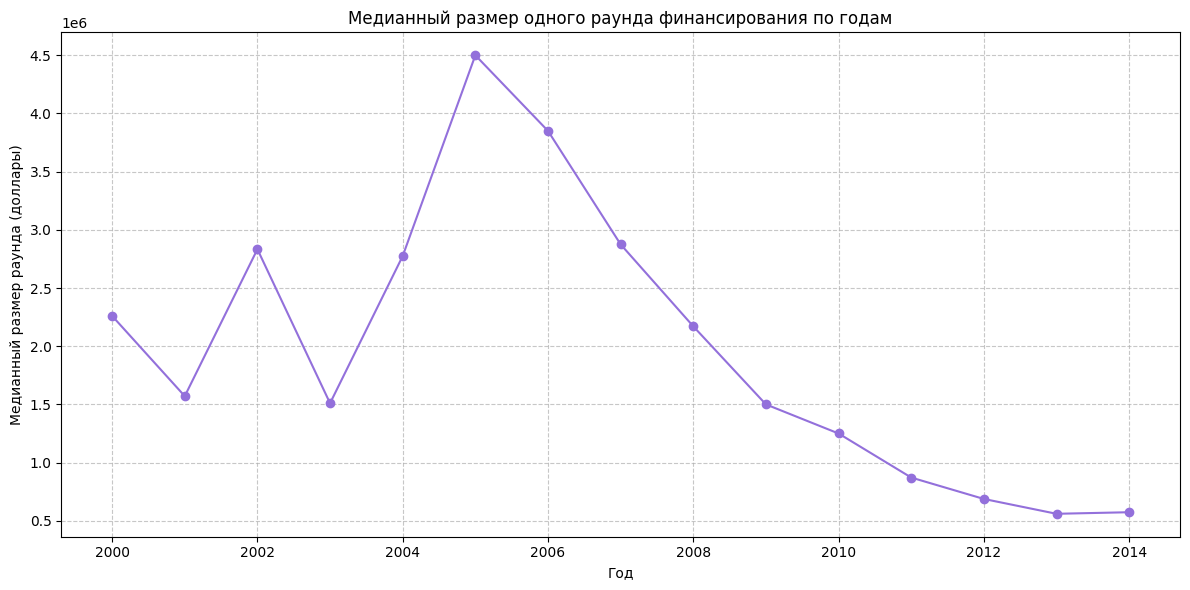

Медианный объем средств одного раунда по годам по убыванию:


mid_funding_at
2005   4500000.00
2006   3850000.00
2007   2875000.00
2002   2833333.33
2004   2775000.00
2000   2260233.58
2008   2170743.75
2001   1570886.00
2003   1510000.00
2009   1500000.00
2010   1250000.00
2011    871500.25
2012    687500.00
2014    573517.00
2013    560000.00
Name: mean_value_round, dtype: float64

In [51]:
yearly_median_value = clean_investments_df.groupby(clean_investments_df['mid_funding_at'].dt.year)['mean_value_round'].median()

plt.figure(figsize=(12, 6))
yearly_median_value.plot(marker='o', linestyle='-', color='mediumpurple')
plt.title('Медианный размер одного раунда финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Медианный размер раунда (доллары)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('Медианный объем средств одного раунда по годам по убыванию:')
yearly_median_value.sort_values(ascending=False)

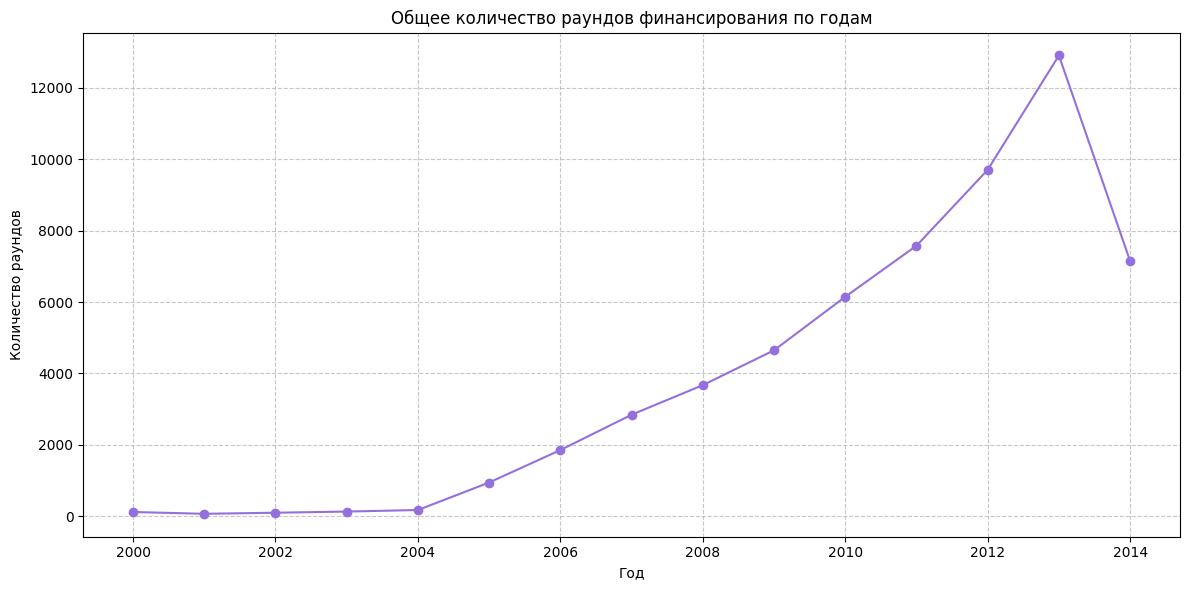

Общее количество раундов финансирования по годам по убыванию


mid_funding_at
2013    12907
2012     9704
2011     7577
2014     7146
2010     6146
2009     4647
2008     3671
2007     2842
2006     1852
2005      943
2004      172
2003      129
2000      117
2002       96
2001       66
Name: funding_rounds, dtype: int64

In [52]:
yearly_round_size = clean_investments_df.groupby(clean_investments_df['mid_funding_at'].dt.year)['funding_rounds'].sum()

plt.figure(figsize=(12, 6))
yearly_round_size.plot(marker='o', linestyle='-', color='mediumpurple')
plt.title('Общее количество раундов финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Количество раундов')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('Общее количество раундов финансирования по годам по убыванию')
yearly_round_size.sort_values(ascending=False)

На построенных графиках можем увидеть, что максимальным среди типичных объемов финансирования в рамках одного раунда был **объем 4.5 млн.** в 2005 году.

В 2014 году кол-во раундов финансирования снизилось после пика кол-ва в 2013 году.

Объем финансирования, выделяемый в рамках каждого раунда незначительно вырос относительно 2013 года.

Тенденция по типичному размеру финансирования в 2014 году - сохраняется на уровне двух предыдущих лет, не хватает данных, чтобы утверждать, что закрепилась тенденция на увеличение среднего размера средств. Можно утверждать что объём среднего раунда инвестиции перестал падать.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассмотрим только массовые сегменты.

На основе графика сделаем вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [53]:
# Создадим сводную таблицу
pivot_invest = pd.pivot_table(
    clean_investments_df[(clean_investments_df['category_market'] == 'Массовые') &
                         (clean_investments_df['market'] != '')],
    index=clean_investments_df['mid_funding_at'].dt.year,
    columns='market',
    values='funding_total_usd',
    aggfunc='sum',
    fill_value=0
    )

pivot_invest

market,Advertising,Analytics,Apps,Automotive,Big Data,Biotechnology,Clean Technology,Cloud Computing,Consulting,Curated Web,...,Sports,Startups,Technology,Travel,Video,Web Hosting,E-Commerce,Mobile,Software,Software
mid_funding_at,,,,,,,,,,,,,,,,,,,,,
2000,14470000.00,14822803.00,0.00,0.00,0.00,0.00,0.00,11500000.00,4500000.00,1000000.00,...,0.00,0.00,0.00,50230.00,0.00,95343090.00,0.00,0.00,0.00,0.00
2001,8778321.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,305000.00,...,0.00,0.00,22160000.00,0.00,0.00,15000000.00,0.00,0.00,0.00,20500000.00
2002,24500000.00,7500000.00,0.00,0.00,0.00,0.00,34390435.00,0.00,0.00,4650000.00,...,200000.00,0.00,2500000.00,0.00,0.00,0.00,0.00,0.00,0.00,14650003.00
2003,0.00,0.00,0.00,4530000.00,0.00,66311685.00,50352939.00,0.00,0.00,250000.00,...,0.00,0.00,0.00,0.00,5000000.00,0.00,0.00,0.00,0.00,26382837.00
2004,6000000.00,3000000.00,0.00,0.00,0.00,97184859.00,0.00,0.00,0.00,13550000.00,...,0.00,0.00,1750000.00,10230000.00,14704000.00,16000000.00,0.00,6230899.00,0.00,0.00
2005,104596022.00,67857500.00,0.00,22500000.00,0.00,477673583.00,19420000.00,0.00,42862000.00,53450000.00,...,1882200.00,0.00,50728425.00,27830000.00,5000000.00,483332632.00,0.00,4868970.00,12960000.00,58030000.00
2006,252853208.00,139701311.00,1310600.00,12660000.00,0.00,903500543.00,131473889.00,9666354.00,23965548.00,142588683.00,...,0.00,0.00,22791000.00,11700000.00,55321772.00,649959267.00,1120000.00,5089961.00,14990000.00,54500000.00
2007,605625667.00,98829000.00,0.00,37612601.00,7780000.00,1599044260.00,726877239.00,20354343.00,83846345.00,267939813.00,...,5651580.00,0.00,180190209.00,12700000.00,71380644.00,358521449.00,0.00,17877080.00,73617182.00,65133032.00
2008,598009546.00,146645600.00,4300000.00,33870829.00,2452515.00,1716033000.00,2981122904.00,44375000.00,18361080.00,294229503.00,...,9354790.00,5010387.00,338226238.00,53405631.00,37865177.00,724976760.00,5558510.00,12920000.00,39595652.00,142116252.00


In [54]:
# Отбор сегментов с ростом в 2014 относительно 2013
if 2013 in pivot_invest.index and 2014 in pivot_invest.index:
    up_segment = pivot_invest.columns[pivot_invest.loc[2014] > pivot_invest.loc[2013]]
    
pivot_invest[up_segment]

market,Apps,Cloud Computing,Entertainment,Internet,Medical,Networking,Photography,Real Estate,Startups,Technology,Video,E-Commerce
mid_funding_at,,,,,,,,,,,,
2000,0.00,11500000.00,100000.00,10000000.00,24000000.00,0.00,0.00,2500000.00,0.00,0.00,0.00,0.00
2001,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,22160000.00,0.00,0.00
2002,0.00,0.00,0.00,1100000.00,0.00,0.00,0.00,5275000.00,0.00,2500000.00,0.00,0.00
2003,0.00,0.00,0.00,0.00,0.00,0.00,7100000.00,6292200.00,0.00,0.00,5000000.00,0.00
2004,0.00,0.00,0.00,10500000.00,0.00,0.00,0.00,0.00,0.00,1750000.00,14704000.00,0.00
2005,0.00,0.00,10000000.00,1775000.00,11090000.00,0.00,7000000.00,250000.00,0.00,50728425.00,5000000.00,0.00
2006,1310600.00,9666354.00,1800000.00,5000.00,20250000.00,26889850.00,17936406.00,2080000.00,0.00,22791000.00,55321772.00,1120000.00
2007,0.00,20354343.00,31224025.00,4455379.00,2100000.00,43745721.00,21315000.00,19710000.00,0.00,180190209.00,71380644.00,0.00
2008,4300000.00,44375000.00,11150000.00,21412964.00,28812744.00,30807000.00,28949322.00,46613100.00,5010387.00,338226238.00,37865177.00,5558510.00


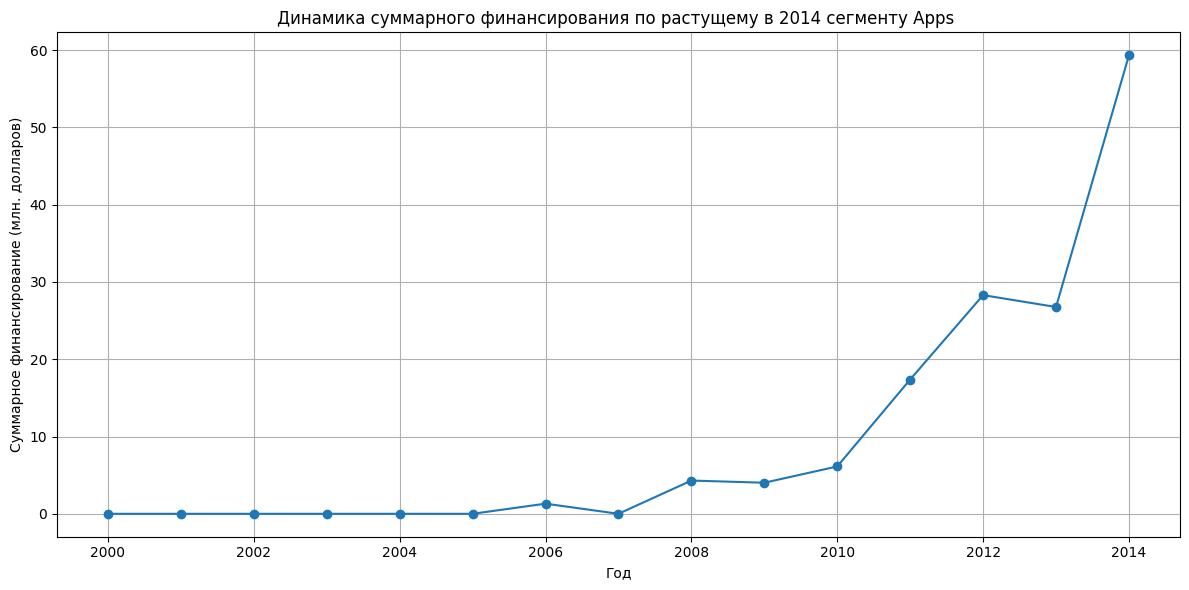

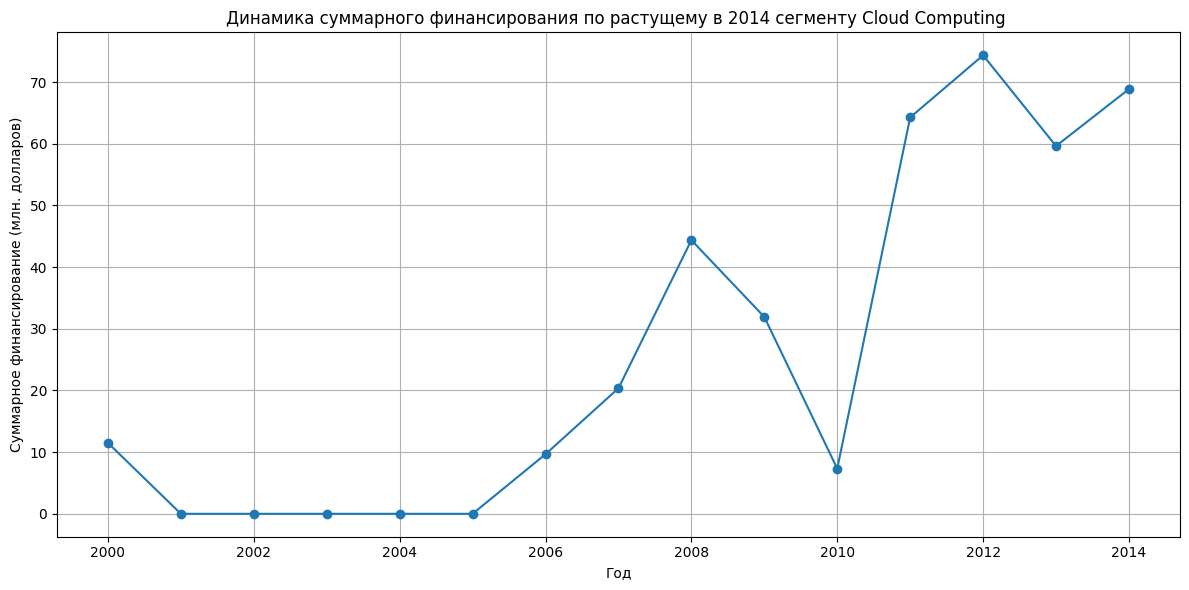

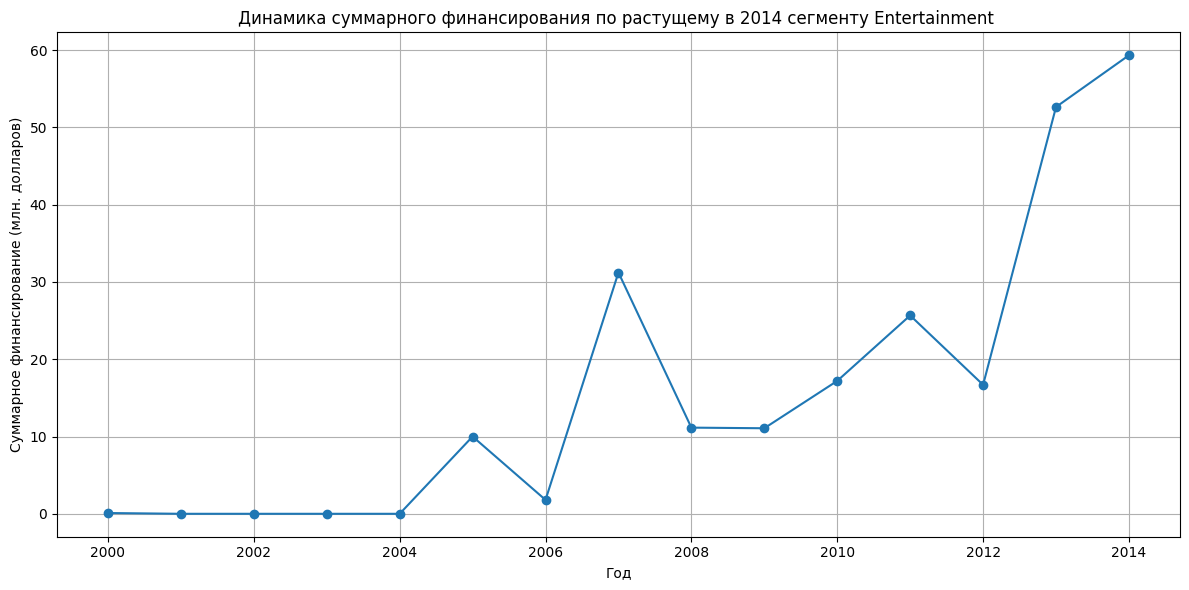

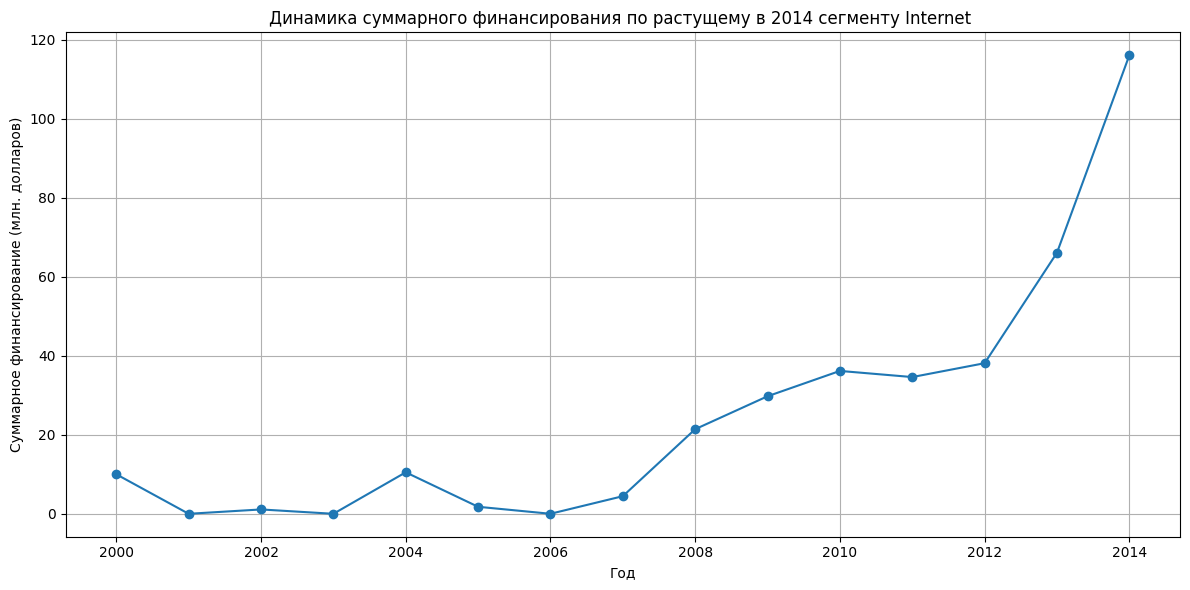

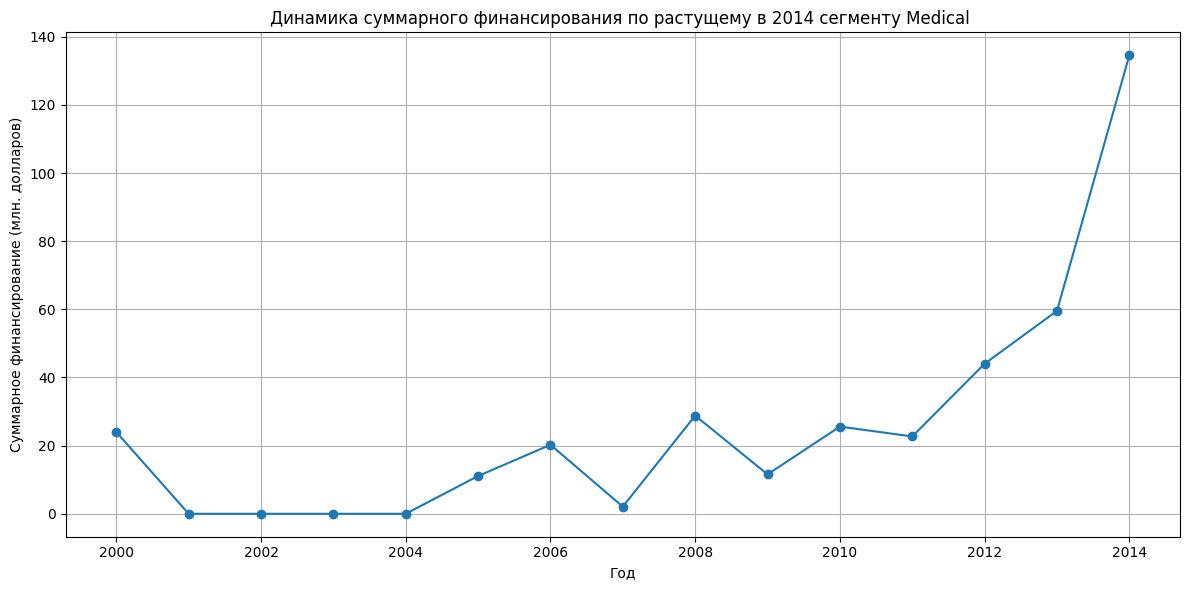

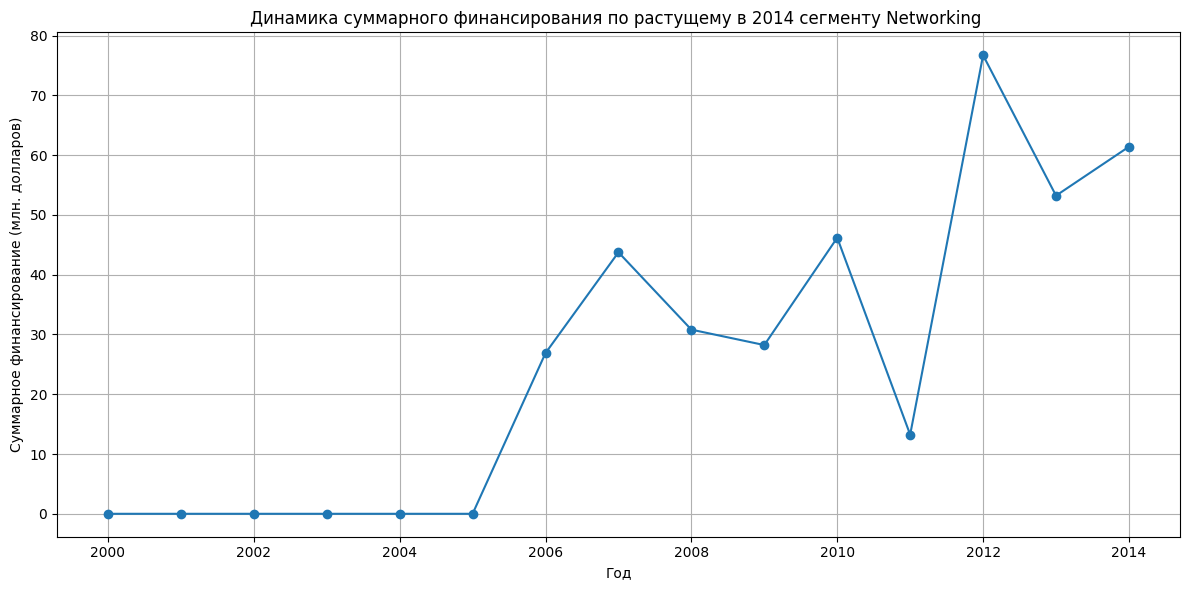

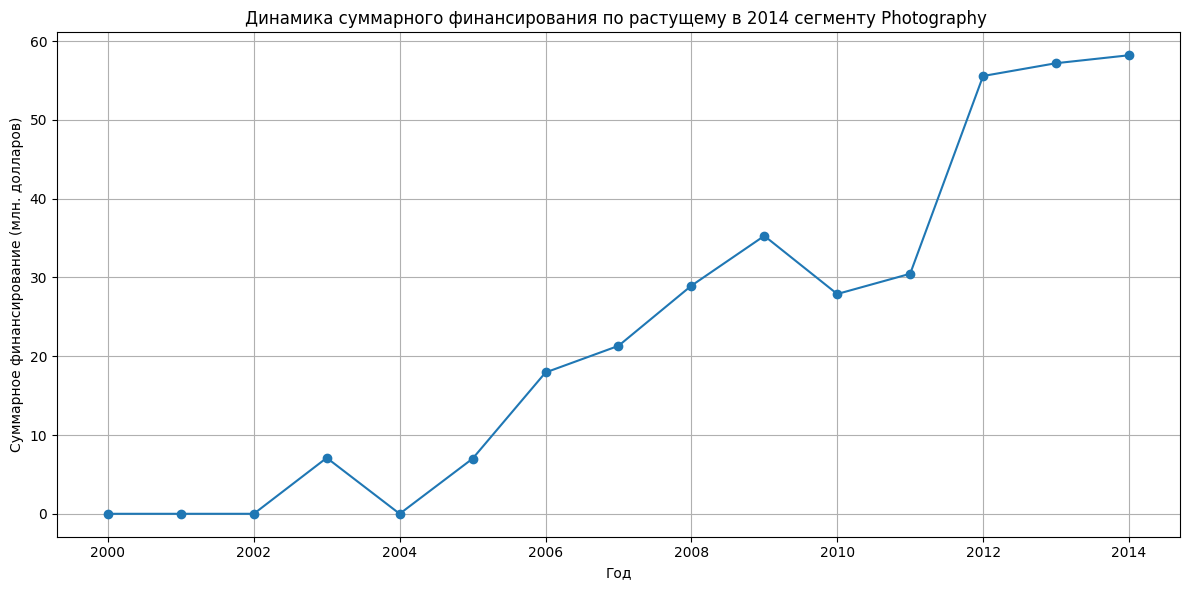

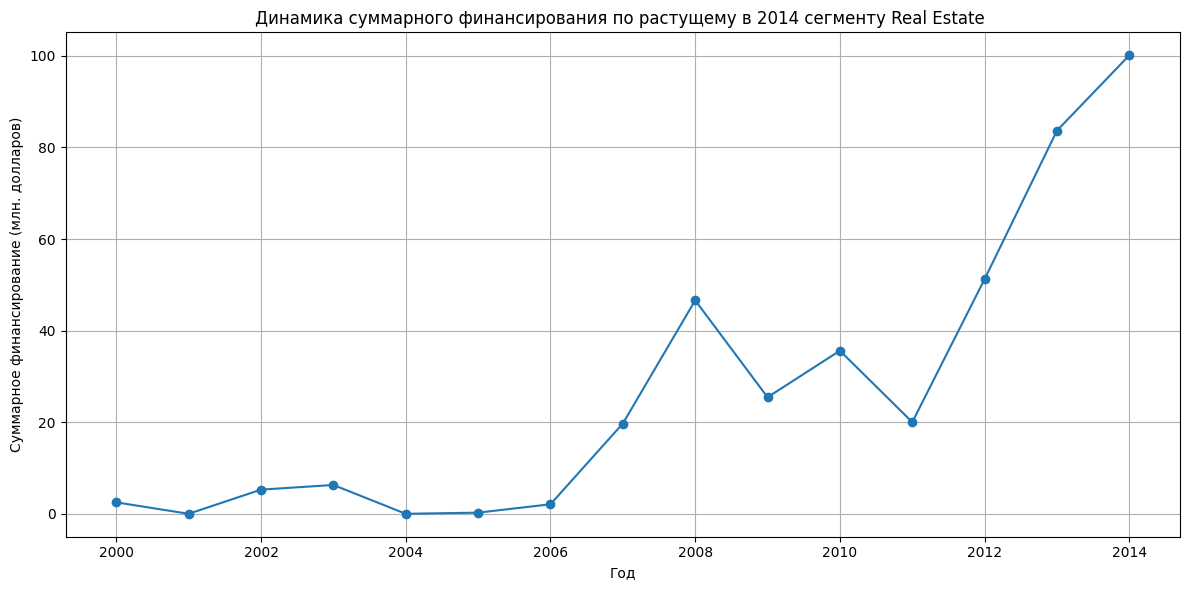

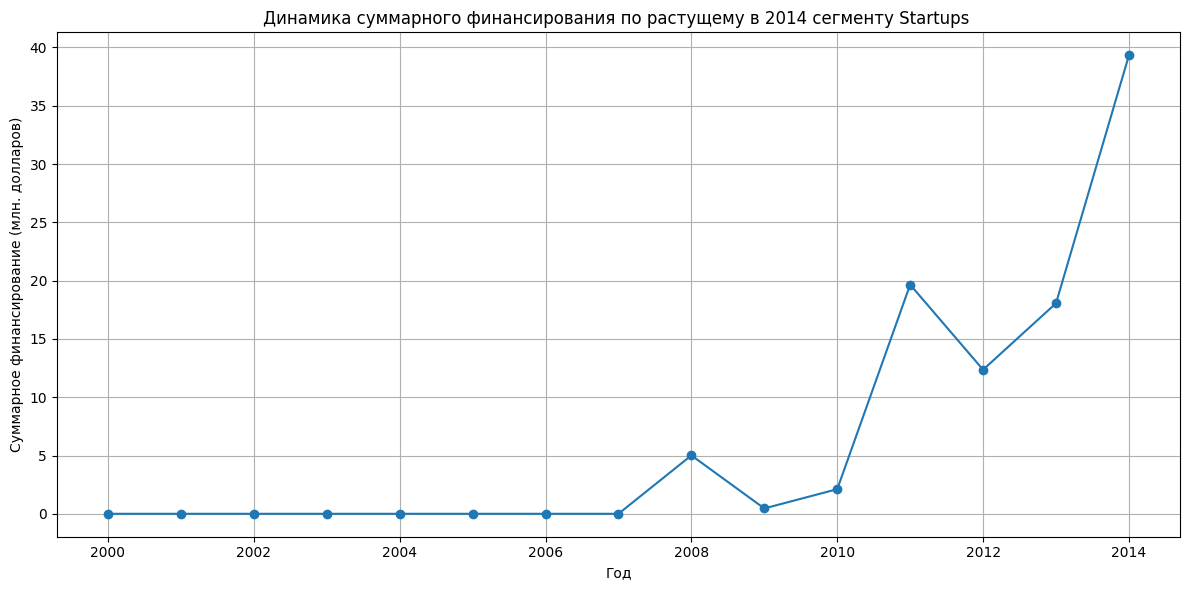

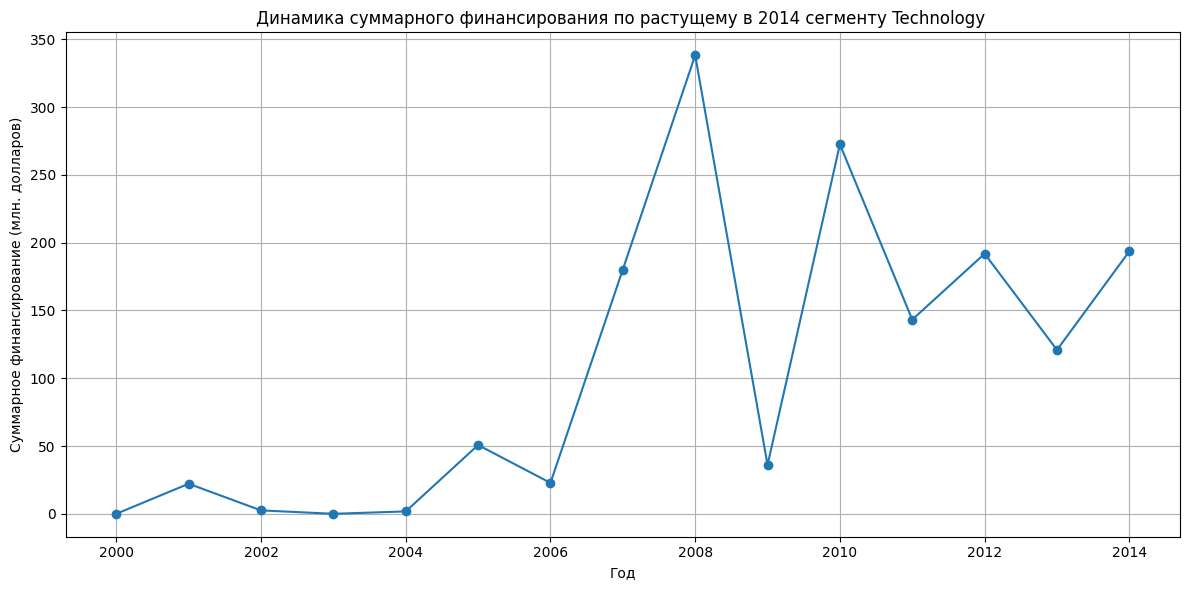

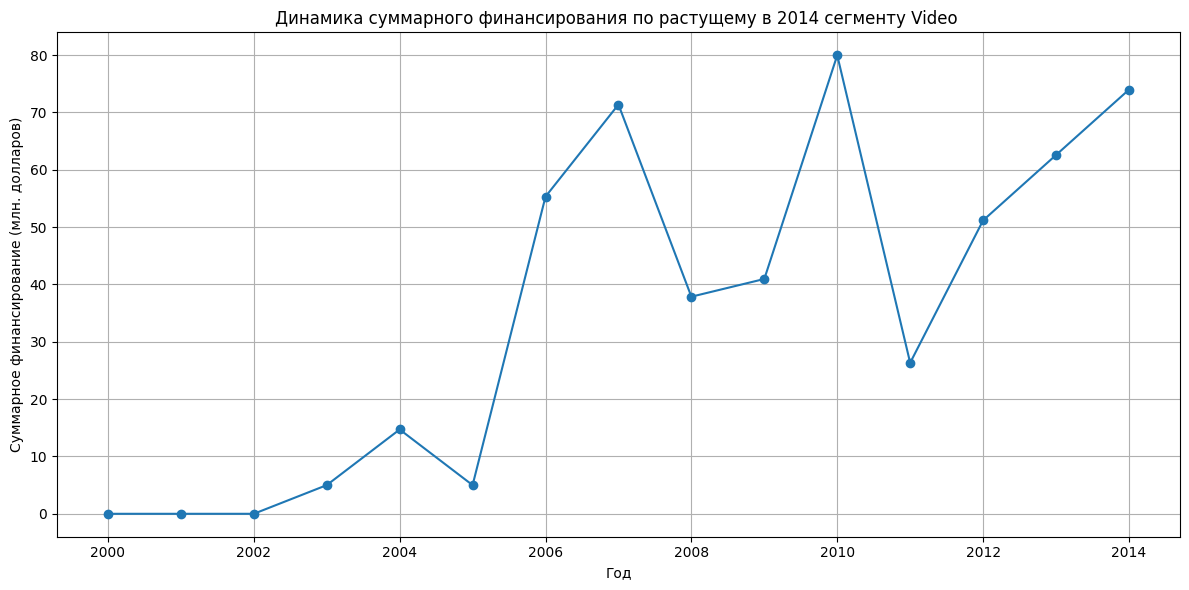

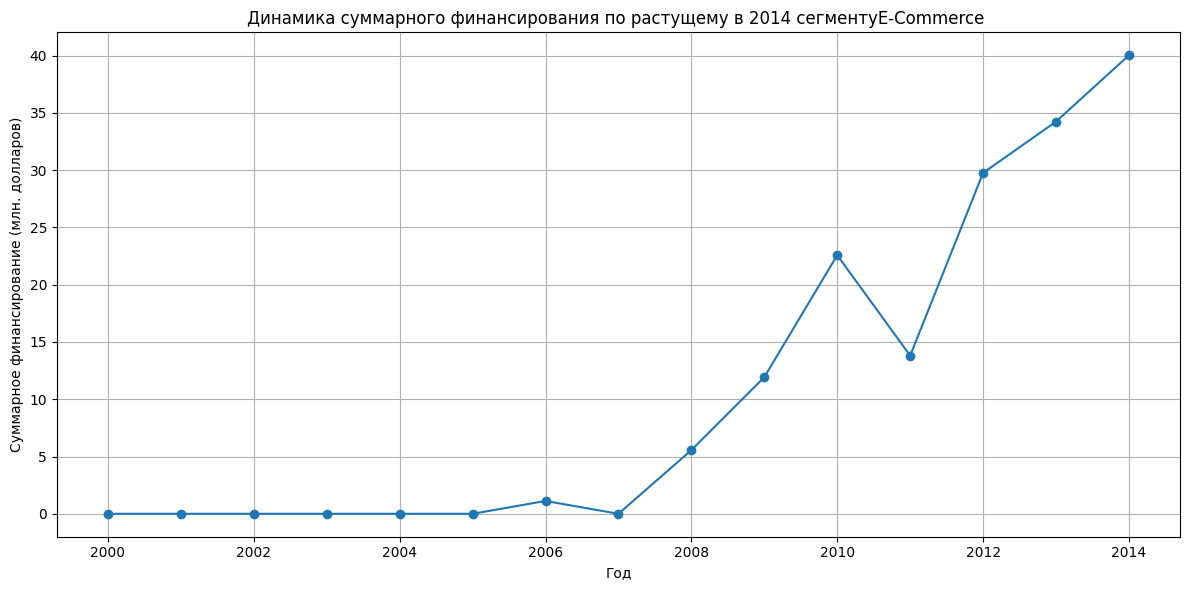

In [55]:
# Построим график динамики всех растущих сегментов в сотнях млн. долларов
up_segment_data = pivot_invest[up_segment]

for seg in up_segment_data:
    plt.figure(figsize= (12, 6))
    plt.plot(up_segment_data.index, up_segment_data[seg] / 1e6, marker='o', label=seg)
    plt.title(f'Динамика суммарного финансирования по растущему в 2014 сегменту{seg}')
    plt.xlabel('Год')
    plt.ylabel('Суммарное финансирование (млн. долларов)')
    plt.grid(True)
    plt.tight_layout()
    plt.show() 

На основе графиков, можно выделить сегменты **Internet, Medical, Real Estate**, которые показывают быстрый и уверенный рост по годам в cотнях миллионов долларов

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Наша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, заменим на пропуски.

Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделаем вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

In [55]:
# Сгруппируем дф по годам и приведем все объемы инвестиций к миллионам
invest_year = clean_investments_df.groupby(clean_investments_df['mid_funding_at'].dt.year)[funding_types].sum() / 1e6
invest_year

In [56]:
joined = invest_year.join(return_df, how='inner', lsuffix='_inv', rsuffix='_ret')
joined

In [57]:
eps = 1e-60 # чтобы избежать деления на ноль

# Рассчитаем долю возварта для каждого типа финансирования
for type in funding_types:
    inv_col = f'{type}_inv'
    ret_col = f'{type}_ret'
    joined[f'{type}_return_ratio'] = round(joined[ret_col] / (joined[inv_col] + eps), 2)

joined

In [58]:
# Избавимся от аномальных значений доли возврата 
for ft in funding_types:
    col = f"{ft}_return_ratio"
    joined[col] = joined[col].where((joined[col] >= 0) & (joined[col] <= 5), other=np.nan)

In [59]:
# Сбросим индекс в датфрейме
joined = joined.reset_index()

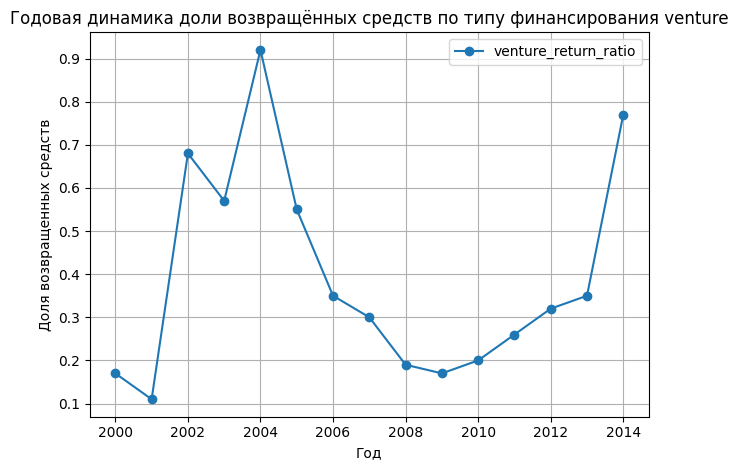

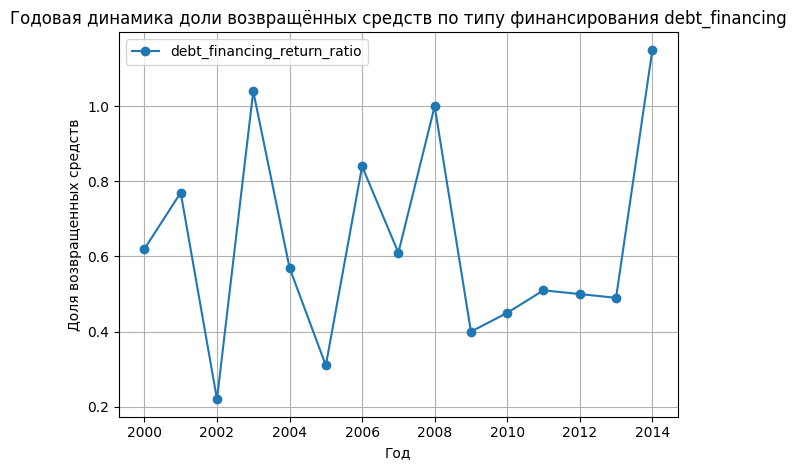

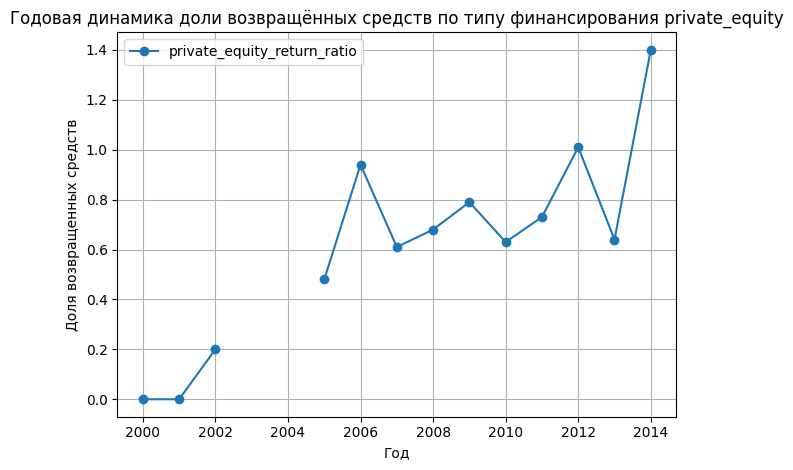

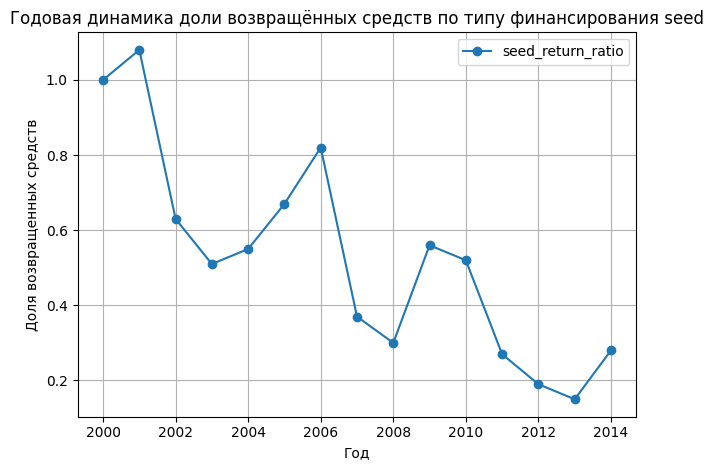

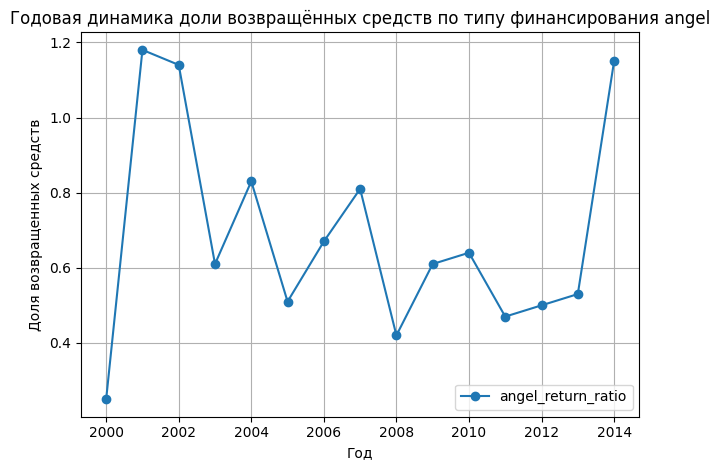

In [60]:
# Построим график на выбранных типах финансирования
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

for type in selected_types:
    plt.figure(figsize=(12, 6))
    joined.plot.line(x='mid_funding_at', y=f'{type}_return_ratio', marker='o', linestyle='-')
    plt.title(f'Годовая динамика доли возвращённых средств по типу финансирования {type}')
    plt.xlabel('Год')
    plt.ylabel('Доля возвращенных средств')
    plt.grid(True)
    plt.tight_layout()
    plt.show() 
    

Среди выбранных типов финансирования, тип **private_equity (частые вложения)** показывает самый стабильный рост по доли возращаемых средств с 2000 по 2014.

Также можно выделить тип **venture (венчурные инвестиции)**, но там иная ситуация - после сильного падения в 2004 году, доля возвращаемых средств начала активно расти только с 2009 года.

Остальные типы **angel, debt_financing** являются волатильными и не показывают стабильного роста. Тип **seed** показывает планомерное снижение доли возращаемых средств за весь временной отрезок с 2000 по 2014


## Шаг 5. Итоговый вывод и рекомендации

Представим, что на календаре 2015 год. Опираясь на результаты анализа, дадим рекомендацию заказчику:

* в какую отрасль стоит инвестировать?

На основе данных и построенных графиков можно выделить сегменты **Internet, Medical, Real Estate**, которые среди остальных сегментов показывают быстрый и уверенный рост по годам в сотнях млн. долларов без особых спадов и коррекций к 2014 году.

* какой тип финансирования при этом будет наиболее уместным?

**Private_equity (частые вложения)** и **venture (венчурные инвестиции)** показывают стабильный рост доли возвращаемых средств инвестору на основе приведенных графиков по расчетным данным. Поэтому при выборе типа финансирования более уместно выбирать из этих двух типов.

Подведем итоги проекта:

* Выполненные шаги:

Загружены и предобработаны данные: удалены пропуски, дубликаты, приведены типы, заполнены пропуски в `mid_funding_at`.

Созданы категории по срокам финансирования и типам рынка (массовые/средние/нишевые).

Выявлены и удалены аномалии по объёму финансирования (IQR), исключены года с <50 раундами финансирования.

Проанализированы объёмы, популярность и возвраты по типам финансирования.

Построена динамика среднего размера раунда и общего числа раундов по годам.

Выделены массовые сегменты с ростом в 2014 году и проанализирована их динамика.

* Основные выводы:

58.9% компаний имеют только один раунд, но 62% инвестиций уходят в компании с финансированием >1 года.

Венчурные инвестиции — лидер по объёму ($128.8 млрд) и возвратам ($40.6 млрд). Гранты популярны, но возвращают 0.

Максимальный медианный размер раунда — в 2005 году ($4.5 млн), после 2008 года снижается до ~$0.56 млн в 2013–2014.

Пик числа раундов — 2013 год (12 907), в 2014 спад до 7 146 (возможно, из-за неполноты данных).

В 2014 году уверенный рост в сегментах Internet, Medical, Real Estate.

* Согласованность и Сомнения:

Логично и взаимосвязано то, что лидером как по привлечению, так и по возрату средств является **venture (венчурные инвестиции)**. Также логично, что в долгосрочных проектах (**финансирование более года**), заложена самая большая доля инвестицией **0.62**

Неполнота данных за декабрь 2014 может искажать спад активности в кол-ве мединных раундов финансирования